# 01 — Data Cleaning & Exploratory Data Analysis

**Project:** Gaming Launch Intelligence — Predicting Commercial Success and Optimising Platform & Launch Strategy

**Objective:** Load the raw VGChartz dataset, apply cleaning rules independently from the SQL pipeline, and conduct a thorough exploratory analysis with visualisations to understand the dataset before statistical testing.

---

## 1. Setup & Imports

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import warnings

# Ensure Plotly charts render as static images on GitHub
pio.renderers.default = 'png'

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

FIGURES_DIR = '../outputs/figures'
SQL_RESULTS_DIR = '../../SQL_Analysis/Result'
RAW_CSV = '../../Game_Data/vgchartz-2024.csv'

# Roll-up/storefront console codes to exclude
EXCLUDED_CONSOLES = {'ALL', 'SERIES', 'XBL', 'PSN', 'DSIW', 'VC', 'MS'}

## 2. Data Loading

Load the raw VGChartz CSV and take a first look at its shape, dtypes, and sample rows.

In [88]:
raw = pd.read_csv(RAW_CSV)
print(f'Raw dataset: {raw.shape[0]:,} rows × {raw.shape[1]} columns')
raw.head()

Raw dataset: 64,016 rows × 14 columns


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


In [89]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  str    
 1   title         64016 non-null  str    
 2   console       64016 non-null  str    
 3   genre         64016 non-null  str    
 4   publisher     64016 non-null  str    
 5   developer     63999 non-null  str    
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  str    
 13  last_update   17879 non-null  str    
dtypes: float64(6), str(8)
memory usage: 6.8 MB


In [90]:
raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
img,64016,56177,/games/boxart/default.jpg,7810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,64016,39798,Plants vs. Zombies,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
console,64016,81,PC,12617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,64016,20,Misc,9304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,64016,3383,Unknown,8842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,63999,8862,Unknown,4435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
critic_score,6678.0,NaN,NaN,NaN,7.22044,1.457066,1.0,6.4,7.5,8.3,10.0
total_sales,18922.0,NaN,NaN,NaN,0.349113,0.807462,0.0,0.03,0.12,0.34,20.32
na_sales,12637.0,NaN,NaN,NaN,0.26474,0.494787,0.0,0.05,0.12,0.28,9.76
jp_sales,6726.0,NaN,NaN,NaN,0.102281,0.168811,0.0,0.02,0.04,0.12,2.13


## 3. Missing Data Profiling

Understanding missingness is critical before any cleaning. We need to know which fields have nulls, how many, and whether the pattern is random or systematic.

In [91]:
# Missing value counts and percentages
missing = pd.DataFrame({
    'null_count': raw.isnull().sum(),
    'null_pct': (raw.isnull().sum() / len(raw) * 100).round(2)
}).sort_values('null_pct', ascending=False)
missing[missing['null_count'] > 0]

,null_count,null_pct
critic_score,57338,89.57
jp_sales,57290,89.49
na_sales,51379,80.26
pal_sales,51192,79.97
other_sales,48888,76.37
last_update,46137,72.07
total_sales,45094,70.44
release_date,7051,11.01
developer,17,0.03


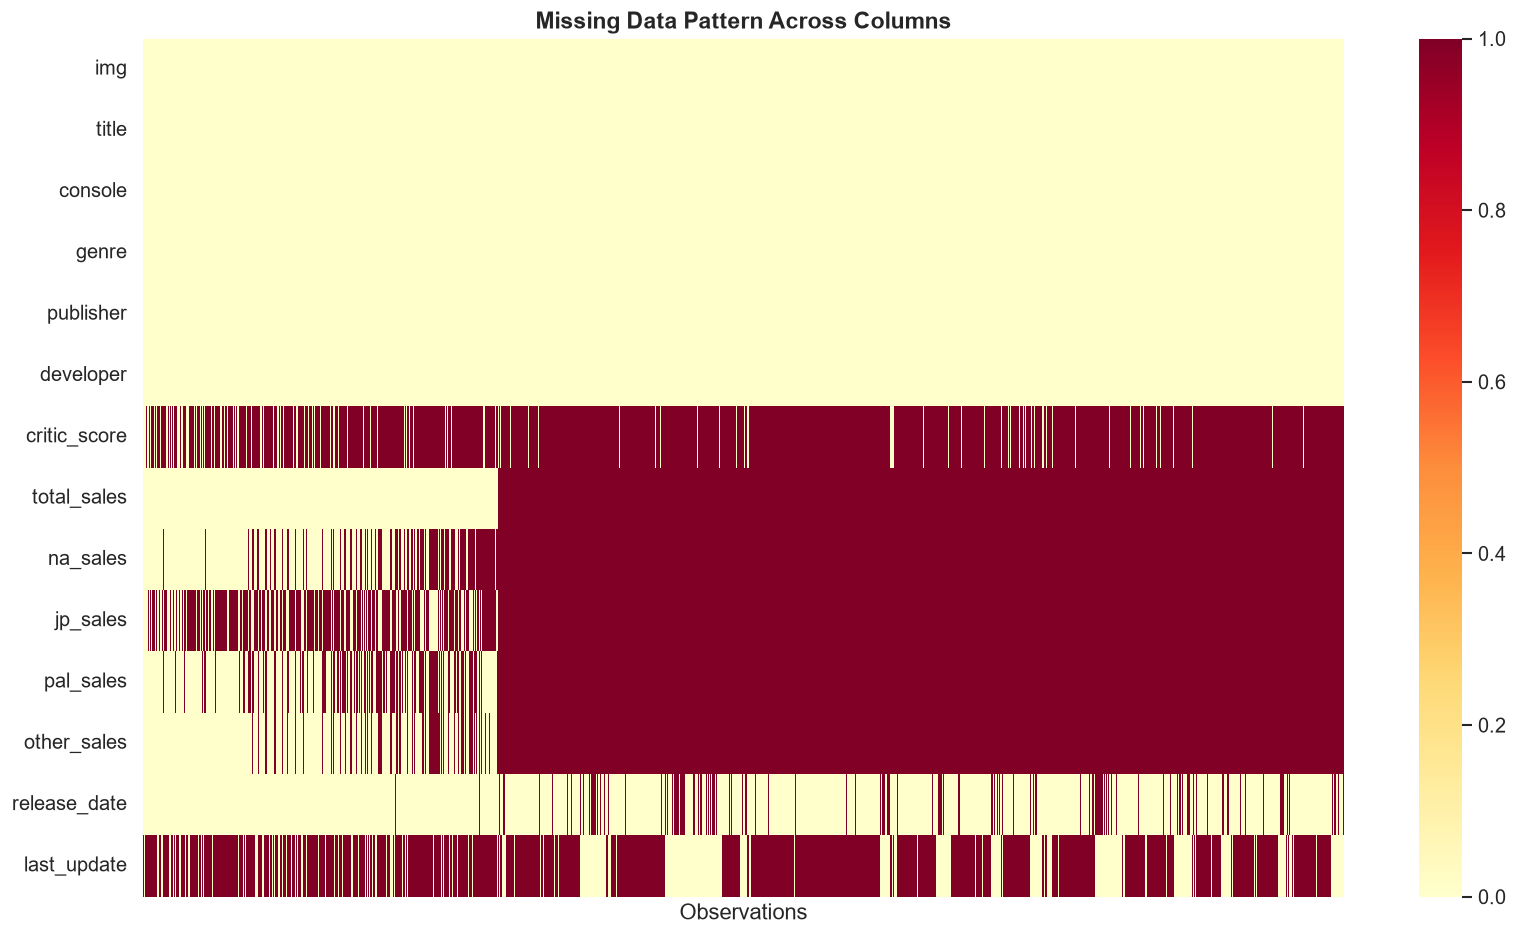

In [92]:
# Missing data heatmap — visualise patterns across columns
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    raw.isnull().T, cbar=True, cmap='YlOrRd',
    yticklabels=raw.columns, xticklabels=False, ax=ax
)
ax.set_title('Missing Data Pattern Across Columns', fontsize=14, fontweight='bold')
ax.set_xlabel('Observations')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/missing_data_heatmap.png', bbox_inches='tight')
plt.show()

## 4. Data Cleaning

Applying the same business rules used in the SQL pipeline, independently implemented in Python:

1. **Retain only sales-populated rows** — rows without `total_sales` are scrape artifacts
2. **Exclude roll-up/storefront records** — synthetic console codes (ALL, SERIES, XBL, etc.)
3. **Type conversions** — parse sales as numeric, dates from DD-MM-YYYY
4. **Standardise text** — title casing for names, uppercase for platform codes
5. **Remove impossible values** — negative sales
6. **Deduplicate** — per (title, console, publisher, release_date), keep the highest-selling row

In [93]:
# Step 1: Parse sales columns to numeric (coerce errors to NaN)
sales_cols = ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
for col in sales_cols:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

# Step 2: Parse critic_score
raw['critic_score'] = pd.to_numeric(raw['critic_score'], errors='coerce')

# Step 3: Parse dates safely
raw['release_date'] = pd.to_datetime(raw['release_date'].astype(str).str.strip(), format='%d-%m-%Y', errors='coerce')
raw['last_update'] = pd.to_datetime(raw['last_update'].astype(str).str.strip(), format='%d-%m-%Y', errors='coerce')

print(f'After type conversions: {raw.shape[0]:,} rows')

After type conversions: 64,016 rows


In [94]:
# Step 4: Retain only sales-populated commercial observations
df = raw[raw['total_sales'].notna()].copy()
print(f'After filtering to sales-populated rows: {df.shape[0]:,} rows')

# Step 5: Exclude roll-up/storefront records
df['console'] = df['console'].astype(str).str.strip().str.upper()
df = df[~df['console'].isin(EXCLUDED_CONSOLES)]
print(f'After excluding roll-up consoles: {df.shape[0]:,} rows')

# Step 6: Remove rows missing critical fields
df['title'] = df['title'].astype(str).str.strip()
df = df[df['title'].ne('') & df['title'].ne('nan')]
df = df[df['console'].ne('') & df['console'].ne('nan')]
print(f'After removing empty title/console: {df.shape[0]:,} rows')

After filtering to sales-populated rows: 18,922 rows
After excluding roll-up consoles: 18,893 rows
After removing empty title/console: 18,893 rows


In [95]:
# Step 7: Standardise text
df['title'] = df['title'].str.title()
df['genre'] = df['genre'].astype(str).str.strip().str.title().replace({'': np.nan, 'Nan': np.nan})
df['publisher'] = df['publisher'].astype(str).str.strip().str.title().replace({'': 'Unknown', 'Nan': 'Unknown'})
df['developer'] = df['developer'].astype(str).str.strip().replace({'': np.nan, 'Nan': np.nan})

# Step 8: Remove negative sales
mask_negative = (
    (df['total_sales'] < 0) |
    (df[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']].fillna(0) < 0).any(axis=1)
)
df = df[~mask_negative]
print(f'After removing negative sales: {df.shape[0]:,} rows')

After removing negative sales: 18,893 rows


In [96]:
# Step 9: Deduplicate scrape records
# Per (title, console, publisher, release_date) keep the row with highest total_sales
df['_title_lower'] = df['title'].str.lower()
df['_publisher_lower'] = df['publisher'].str.lower()

df = df.sort_values(
    ['total_sales', 'last_update', 'critic_score'],
    ascending=[False, False, False],
    na_position='last'
)

df = df.drop_duplicates(
    subset=['_title_lower', 'console', '_publisher_lower', 'release_date'],
    keep='first'
)

df = df.drop(columns=['_title_lower', '_publisher_lower'])
print(f'After deduplication: {df.shape[0]:,} rows')

# Add release_year for convenience
df['release_year'] = df['release_date'].dt.year.astype('Int64')

After deduplication: 18,850 rows


In [97]:
# Cross-validate against SQL cleaned row count
sql_clean_count = 18_893  # approximate expected count from SQL pipeline
print(f'Python cleaned rows: {len(df):,}')
print(f'SQL cleaned rows (expected): ~{sql_clean_count:,}')
print(f'Difference: {abs(len(df) - sql_clean_count):,} rows')

Python cleaned rows: 18,850
SQL cleaned rows (expected): ~18,893
Difference: 43 rows


## 5. Cleaned Dataset Overview

In [98]:
print(f'Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nUnique titles:     {df["title"].nunique():,}')
print(f'Unique platforms:  {df["console"].nunique()}')
print(f'Unique genres:     {df["genre"].nunique()}')
print(f'Unique publishers: {df["publisher"].nunique():,}')
print(f'Unique developers: {df["developer"].nunique():,}')
print(f'\nRelease year range: {df["release_year"].min()} – {df["release_year"].max()}')
print(f'Total global sales: ${df["total_sales"].sum():,.2f}M')

Final dataset: 18,850 rows × 15 columns

Unique titles:     12,926
Unique platforms:  36
Unique genres:     20
Unique publishers: 739
Unique developers: 2,862

Release year range: 1977 – 2020
Total global sales: $6,593.70M


In [99]:
df.describe().T.round(4)

,count,mean,min,25%,50%,75%,max,std
critic_score,4107.0,7.102021,1.0,6.3,7.3,8.1,10.0,1.44048
total_sales,18850.0,0.349798,0.0,0.03,0.12,0.35,20.32,0.808432
na_sales,12612.0,0.26511,0.0,0.05,0.12,0.28,9.76,0.495175
jp_sales,6694.0,0.101864,0.0,0.02,0.04,0.12,2.13,0.167128
pal_sales,12784.0,0.149729,0.0,0.01,0.04,0.14,9.85,0.393139
other_sales,15090.0,0.043054,0.0,0.0,0.01,0.03,3.12,0.12646
release_date,18761,2008-04-02 14:47:21.852779,1977-01-01 00:00:00,2004-09-27 00:00:00,2008-10-21 00:00:00,2011-11-08 00:00:00,2020-12-31 00:00:00,NaN
last_update,4006,2018-08-09 05:19:33.639540,2017-12-23 00:00:00,2018-04-02 00:00:00,2018-08-03 00:00:00,2018-11-14 00:00:00,2022-07-10 00:00:00,NaN
release_year,18761.0,2007.685838,1977.0,2004.0,2008.0,2011.0,2020.0,6.034276


## 6. Sales Distribution Analysis

Game sales follow a heavy right skew — a small number of blockbusters generate a disproportionate share of revenue. Understanding this distribution is essential for choosing the right statistical methods downstream.

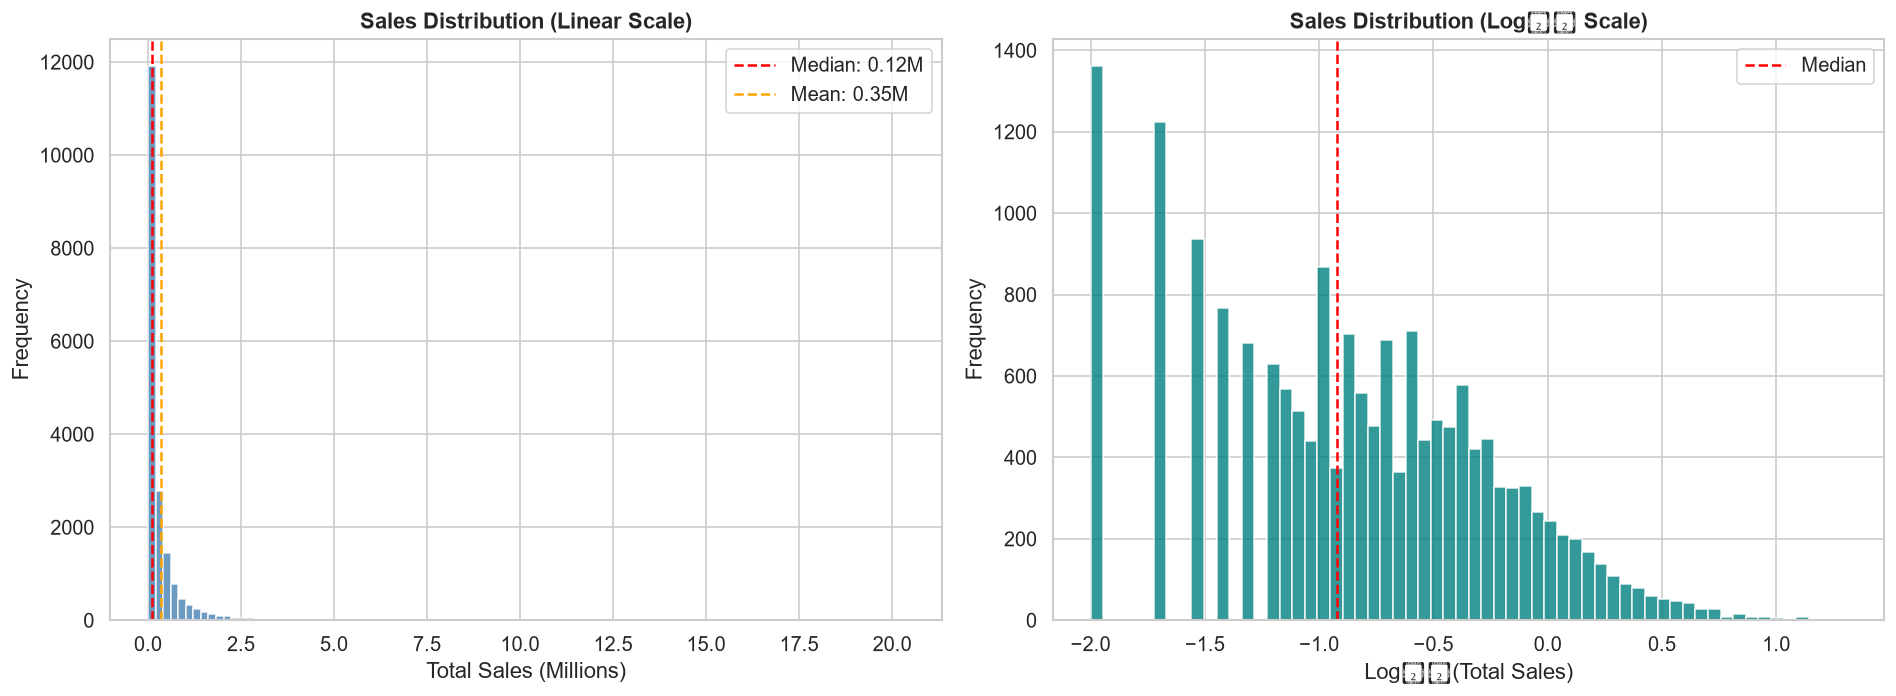

Skewness: 8.77
Kurtosis: 125.39


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale
axes[0].hist(df['total_sales'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['total_sales'].median(), color='red', linestyle='--', label=f'Median: {df["total_sales"].median():.2f}M')
axes[0].axvline(df['total_sales'].mean(), color='orange', linestyle='--', label=f'Mean: {df["total_sales"].mean():.2f}M')
axes[0].set_title('Sales Distribution (Linear Scale)', fontweight='bold')
axes[0].set_xlabel('Total Sales (Millions)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Log scale
log_sales = np.log10(df['total_sales'][df['total_sales'] > 0])
axes[1].hist(log_sales, bins=60, color='teal', edgecolor='white', alpha=0.8)
axes[1].axvline(np.log10(df['total_sales'].median()), color='red', linestyle='--', label=f'Median')
axes[1].set_title('Sales Distribution (Log₁₀ Scale)', fontweight='bold')
axes[1].set_xlabel('Log₁₀(Total Sales)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/sales_distribution.png', bbox_inches='tight')
plt.show()

print(f'Skewness: {df["total_sales"].skew():.2f}')
print(f'Kurtosis: {df["total_sales"].kurtosis():.2f}')

## 7. Top Games by Global Sales

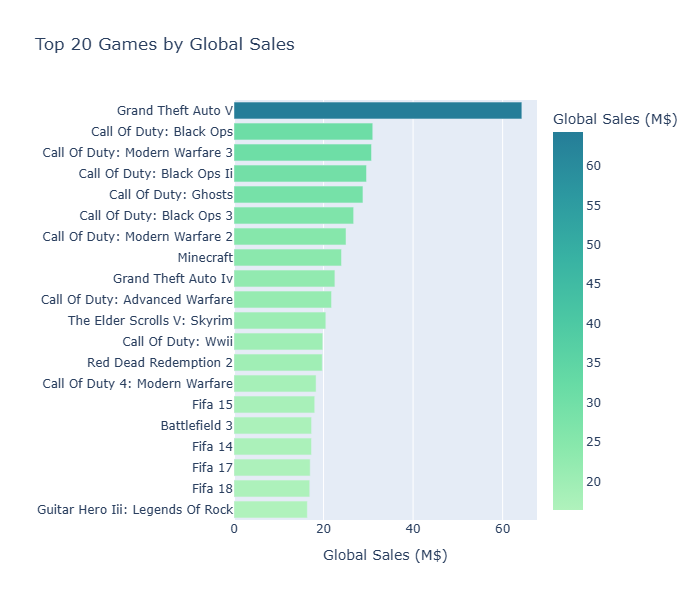

In [101]:
top_games = (
    df.groupby('title')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

fig = px.bar(
    top_games, x='total_sales', y='title',
    orientation='h', color='total_sales',
    color_continuous_scale='Tealgrn',
    labels={'total_sales': 'Global Sales (M$)', 'title': ''},
    title='Top 20 Games by Global Sales'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600, showlegend=False)
fig.write_image(f'{FIGURES_DIR}/`top_20_games.png', scale=2)
fig.show()

## 8. Genre Distribution

Comparing genres by both title count and total sales reveals whether a genre's revenue is driven by volume or by a few high-performing titles.

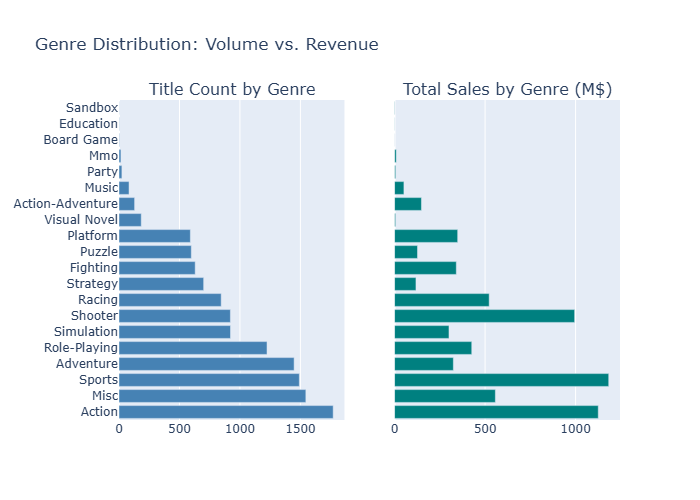

In [102]:
genre_stats = (
    df[df['genre'].notna()]
    .groupby('genre')
    .agg(
        title_count=('title', 'nunique'),
        total_sales=('total_sales', 'sum'),
        median_sales=('total_sales', 'median'),
        avg_sales=('total_sales', 'mean')
    )
    .sort_values('total_sales', ascending=False)
    .reset_index()
)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Title Count by Genre', 'Total Sales by Genre (M$)'],
    shared_yaxes=True
)

fig.add_trace(
    go.Bar(x=genre_stats['title_count'], y=genre_stats['genre'],
           orientation='h', marker_color='steelblue', name='Titles'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=genre_stats['total_sales'], y=genre_stats['genre'],
           orientation='h', marker_color='teal', name='Sales'),
    row=1, col=2
)

fig.update_layout(
    height=500, showlegend=False,
    title_text='Genre Distribution: Volume vs. Revenue',
    yaxis={'categoryorder': 'total ascending'}
)
fig.write_image(f'{FIGURES_DIR}/`genre_distribution.png', scale=2)
fig.show()

## 9. Platform Distribution

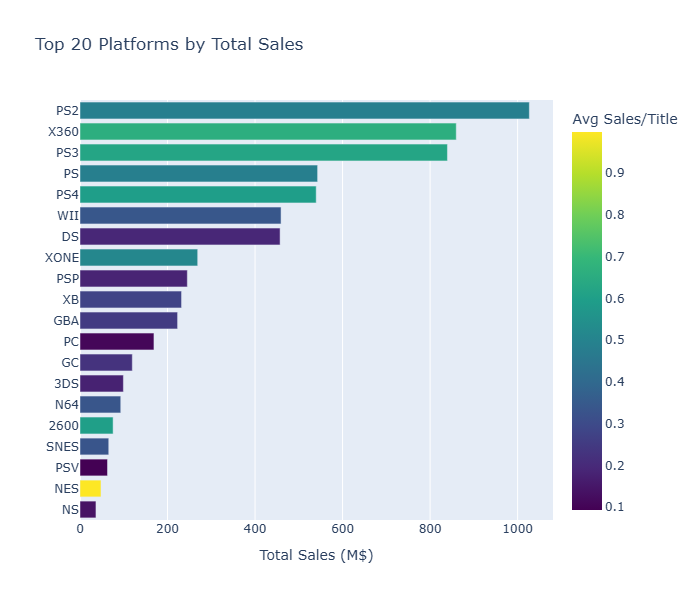

In [103]:
platform_stats = (
    df.groupby('console')
    .agg(
        release_count=('title', 'count'),
        total_sales=('total_sales', 'sum'),
        avg_sales=('total_sales', 'mean'),
        median_sales=('total_sales', 'median')
    )
    .sort_values('total_sales', ascending=False)
    .reset_index()
)

fig = px.bar(
    platform_stats.head(20), x='total_sales', y='console',
    orientation='h', color='avg_sales',
    color_continuous_scale='Viridis',
    hover_data=['release_count', 'median_sales'],
    labels={'total_sales': 'Total Sales (M$)', 'console': '', 'avg_sales': 'Avg Sales/Title'},
    title='Top 20 Platforms by Total Sales'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.write_image(f'{FIGURES_DIR}/`platform_distribution.png', scale=2)
fig.show()

## 10. Temporal Trends

The number of releases and aggregate sales over time reveals the "reliable analysis window" — years with sufficient observations for robust statistical analysis.

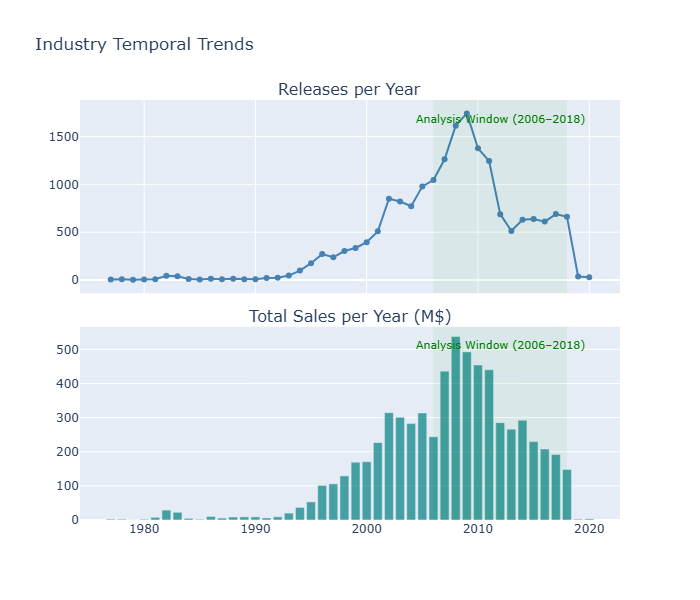

In [104]:
yearly = (
    df[df['release_year'].notna()]
    .groupby('release_year')
    .agg(
        releases=('title', 'count'),
        total_sales=('total_sales', 'sum'),
        avg_sales=('total_sales', 'mean')
    )
    .reset_index()
)

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['Releases per Year', 'Total Sales per Year (M$)'],
    shared_xaxes=True, vertical_spacing=0.08
)

fig.add_trace(
    go.Scatter(x=yearly['release_year'], y=yearly['releases'],
               mode='lines+markers', line=dict(color='steelblue', width=2),
               name='Releases'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=yearly['release_year'], y=yearly['total_sales'],
           marker_color='teal', opacity=0.7, name='Sales'),
    row=2, col=1
)

# Highlight the analysis window (2006-2018)
for row in [1, 2]:
    fig.add_vrect(x0=2006, x1=2018, fillcolor='green', opacity=0.05,
                  line_width=0, row=row, col=1)
    fig.add_annotation(
        x=2012, y=0.95, xref='x', yref='y domain',
        text='Analysis Window (2006–2018)', showarrow=False,
        font=dict(size=11, color='green'), row=row, col=1
    )

fig.update_layout(height=600, showlegend=False, title_text='Industry Temporal Trends')
fig.write_image(f'{FIGURES_DIR}/`temporal_trends.png', scale=2)
fig.show()

## 11. Regional Sales Composition

How sales are distributed across NA, JP, PAL, and Other regions varies significantly by genre — a critical insight for marketing allocation.

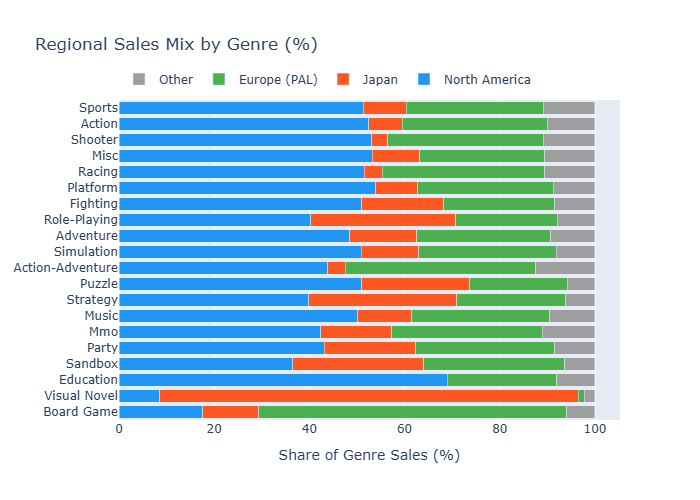

In [105]:
region_by_genre = (
    df[df['genre'].notna()]
    .groupby('genre')[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']]
    .sum()
    .sort_values('na_sales', ascending=True)
)

# Normalise to percentages
region_pct = region_by_genre.div(region_by_genre.sum(axis=1), axis=0) * 100

fig = go.Figure()
colors = {'na_sales': '#2196F3', 'jp_sales': '#FF5722', 'pal_sales': '#4CAF50', 'other_sales': '#9E9E9E'}
labels = {'na_sales': 'North America', 'jp_sales': 'Japan', 'pal_sales': 'Europe (PAL)', 'other_sales': 'Other'}

for col in ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']:
    fig.add_trace(go.Bar(
        y=region_pct.index, x=region_pct[col],
        name=labels[col], orientation='h',
        marker_color=colors[col]
    ))

fig.update_layout(
    barmode='stack', height=500,
    title='Regional Sales Mix by Genre (%)',
    xaxis_title='Share of Genre Sales (%)',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.write_image(f'{FIGURES_DIR}/`regional_composition.png', scale=2)
fig.show()

## 12. Critic Score vs. Sales

Does critical acclaim predict commercial success? This scatter plot with a trend line provides the initial visual signal before formal statistical testing in Notebook 02.

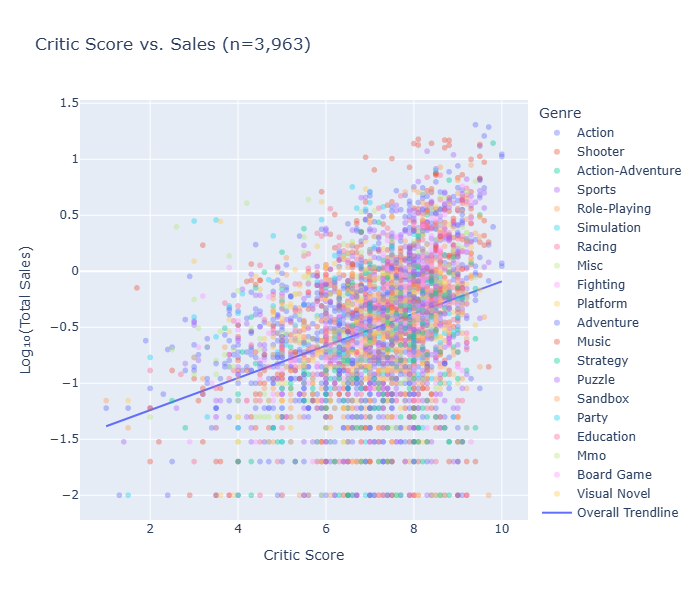

Spearman rank correlation (critic_score vs total_sales): 0.3622


In [106]:
scored = df[df['critic_score'].notna() & (df['total_sales'] > 0)].copy()
scored['log_sales'] = np.log10(scored['total_sales'])

fig = px.scatter(
    scored, x='critic_score', y='log_sales',
    color='genre', opacity=0.4,
    trendline='ols', trendline_scope='overall',
    labels={'critic_score': 'Critic Score', 'log_sales': 'Log₁₀(Total Sales)', 'genre': 'Genre'},
    title=f'Critic Score vs. Sales (n={len(scored):,})',
    hover_data=['title', 'console', 'total_sales']
)
fig.update_layout(height=600)
fig.write_image(f'{FIGURES_DIR}/`critic_vs_sales.png', scale=2)
fig.show()

corr = scored['critic_score'].corr(scored['total_sales'], method='spearman')
print(f'Spearman rank correlation (critic_score vs total_sales): {corr:.4f}')

## 13. Publisher Landscape

Understanding publisher dominance is key to assessing competitive barriers for a new entrant.

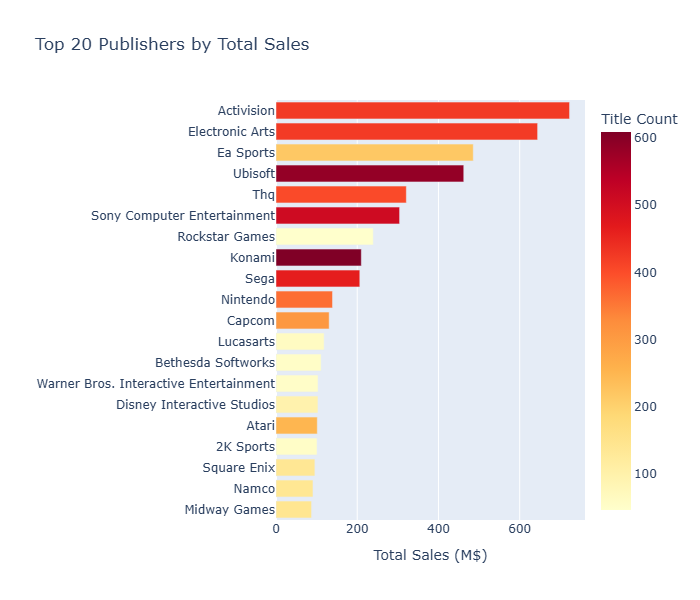

In [107]:
pub_stats = (
    df.groupby('publisher')
    .agg(
        title_count=('title', 'nunique'),
        total_sales=('total_sales', 'sum'),
        avg_sales=('total_sales', 'mean')
    )
    .sort_values('total_sales', ascending=False)
    .head(20)
    .reset_index()
)

fig = px.bar(
    pub_stats, x='total_sales', y='publisher',
    orientation='h', color='title_count',
    color_continuous_scale='YlOrRd',
    hover_data=['avg_sales'],
    labels={'total_sales': 'Total Sales (M$)', 'publisher': '', 'title_count': 'Title Count'},
    title='Top 20 Publishers by Total Sales'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.write_image(f'{FIGURES_DIR}/`publisher_landscape.png', scale=2)
fig.show()

## 14. Genre × Platform Heatmap

Which genres perform best on which platforms? This heatmap reveals the combinations that matter for launch strategy.

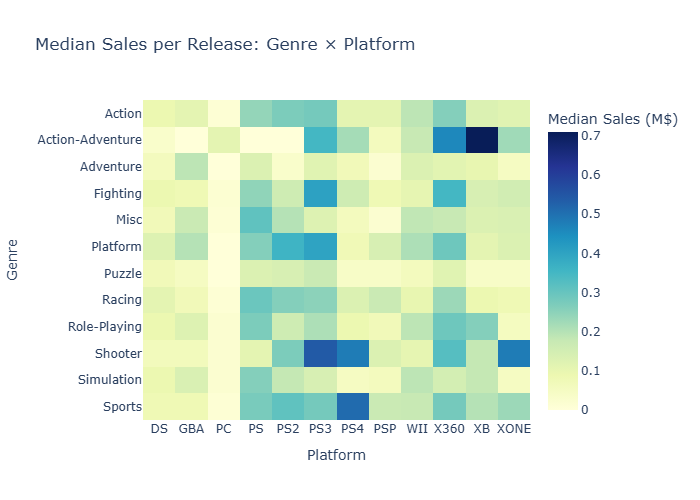

In [108]:
# Filter to top platforms and genres for readability
top_platforms = df.groupby('console')['total_sales'].sum().nlargest(12).index
top_genres = df[df['genre'].notna()].groupby('genre')['total_sales'].sum().nlargest(12).index

gp_pivot = (
    df[(df['console'].isin(top_platforms)) & (df['genre'].isin(top_genres))]
    .groupby(['genre', 'console'])['total_sales']
    .median()
    .unstack(fill_value=0)
)

fig = px.imshow(
    gp_pivot, color_continuous_scale='YlGnBu',
    labels=dict(x='Platform', y='Genre', color='Median Sales (M$)'),
    title='Median Sales per Release: Genre × Platform',
    aspect='auto'
)
fig.update_layout(height=500)
fig.write_image(f'{FIGURES_DIR}/`genre_platform_heatmap.png', scale=2)
fig.show()

## 15. Sales Distribution by Platform & Genre

Box plots reveal the spread, median, and outliers — critical for understanding whether a platform's average is driven by a few hits or by consistently higher sales.

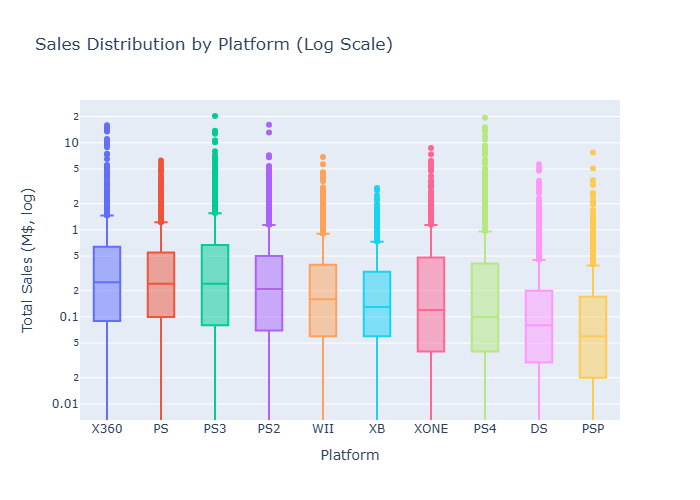

In [109]:
# Platform sales box plot (top 10 platforms, log scale)
top10_plat = df.groupby('console')['total_sales'].sum().nlargest(10).index
plat_df = df[df['console'].isin(top10_plat)]

fig = px.box(
    plat_df, x='console', y='total_sales', color='console',
    log_y=True,
    labels={'total_sales': 'Total Sales (M$, log)', 'console': 'Platform'},
    title='Sales Distribution by Platform (Log Scale)',
    category_orders={'console': plat_df.groupby('console')['total_sales'].median().sort_values(ascending=False).index.tolist()}
)
fig.update_layout(height=500, showlegend=False)
fig.write_image(f'{FIGURES_DIR}/`platform_sales_boxplot.png', scale=2)
fig.show()

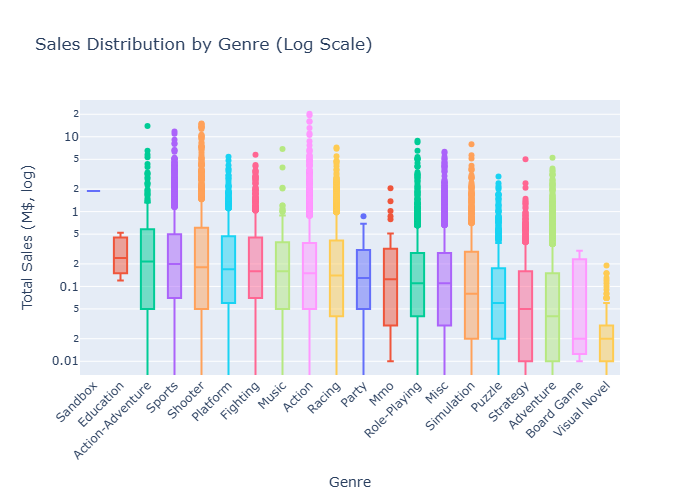

In [110]:
# Genre sales box plot (log scale)
genre_df = df[df['genre'].notna()]

fig = px.box(
    genre_df, x='genre', y='total_sales', color='genre',
    log_y=True,
    labels={'total_sales': 'Total Sales (M$, log)', 'genre': 'Genre'},
    title='Sales Distribution by Genre (Log Scale)',
    category_orders={'genre': genre_df.groupby('genre')['total_sales'].median().sort_values(ascending=False).index.tolist()}
)
fig.update_layout(height=500, showlegend=False, xaxis_tickangle=-45)
fig.write_image(f'{FIGURES_DIR}/`genre_sales_boxplot.png', scale=2)
fig.show()

## 16. Save Cleaned Dataset

Export the cleaned DataFrame for use in subsequent notebooks.

In [111]:
# Save cleaned dataset for notebooks 02 and 03
df.to_csv('../outputs/cleaned_dataset.csv', index=False)
print(f'Saved cleaned dataset: {len(df):,} rows → outputs/cleaned_dataset.csv')

Saved cleaned dataset: 18,850 rows → outputs/cleaned_dataset.csv


---
## Summary

| Metric | Value |
|---|---|
| Raw rows | ~64,000 |
| Cleaned rows | ~18,900 |
| Exclusion reasons | No sales data, roll-up records, duplicates, negative sales |
| Analysis window | 2006–2018 (years with ≥100 observations) |
| Key finding | Sales are heavily right-skewed (median ≪ mean), justifying non-parametric tests |

**Next:** Notebook 02 applies formal statistical tests to validate these exploratory observations.